# SkillBridge — Module 2: Data Preprocessing & Feature Engineering
### KPITB × UETM — AI-Based Career Recommendation, Job Matching & Skill Gap Analysis

## 1. Introduction

**What does Module 2 do?**

Module 1 audited both datasets and told us, using real numbers, what was clean and what was not. Module 2
takes those specific findings and turns the two raw datasets into clean, consistent, machine-ready
datasets — nothing here is invented or generic; every cleaning step below is a direct response to
something actually found in Module 1.

**Why is preprocessing important?**

Raw data almost always has small formatting inconsistencies (extra spaces, inconsistent capitalization),
missing values, or values stored as free text that need to be converted into usable numeric/categorical
fields. If we skip this step, a career-classification model or a job-matching system built later would
either fail to run or would learn from noisy, inconsistent data.

**How are Module 1 findings used here?**

Module 1 found that:
- **Dataset 1** (student skills) had **no missing values, no duplicate rows, and no out-of-range
  numerical values** — so Module 2 focuses mainly on *feature engineering* rather than heavy cleaning.
- **Dataset 2** (job market) had **missing values in `Salary Range (PKR)`, `Experience Required`,
  `Education Level`, and `Gender Preference`**, **inconsistent city spellings/casing** (e.g. `KARACHI`,
  `Karachi`, `karachi`, `Karachì`), and **skills stored as a single comma-separated text field**. Module
  2 addresses each of these directly.

**What will Dataset 1 be prepared for?**

An ML-ready **Student Career Dataset** for career classification (Module 3).

**What will Dataset 2 be prepared for?**

A clean **Job Matching Ready Dataset**, with normalized job titles, structured required skills, parsed
salary/experience fields, and a candidate **Career Mapping Layer** connecting `Career_Field` to real job
titles.

**Important:** Module 2 does **not** train any ML models. Model training starts in Module 3.


## 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)

print("Libraries imported successfully.")


Libraries imported successfully.


## 3. Load the Original Datasets

**What are we doing?**

We load both raw datasets exactly as used in Module 1, and immediately create working copies so the
original raw data is never modified in place.


In [2]:
DATASET_1_PATH = "skillbridge_synthetic_student_skills.csv"
DATASET_2_PATH = "pakistan_job_market_dataset.csv"

df1 = pd.read_csv(DATASET_1_PATH)
df2 = pd.read_csv(DATASET_2_PATH)

print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)


Dataset 1 shape: (6000, 57)
Dataset 2 shape: (10500, 13)


In [3]:
df1.head()


,Student_ID,Age,Gender,University_Year,Major,CGPA,Attendance_Percentage,Study_Hours_Per_Week,Projects_Completed,Certifications_Count,Internships,Communication_Skills,Teamwork,Problem_Solving,Interest_Domain,Skill_AWS,Skill_Adobe_XD,Skill_Agile,Skill_Ansible,Skill_Azure,Skill_CI_CD,Skill_Cybersecurity,Skill_Data_Analysis,Skill_Django,Skill_Docker,Skill_Elasticsearch,Skill_FastAPI,Skill_Figma,Skill_Flutter,Skill_GCP,Skill_Git,Skill_GraphQL,Skill_JavaScript,Skill_Kubernetes,Skill_Laravel,Skill_Linux,Skill_Machine_Learning,Skill_MongoDB,Skill_MySQL,Skill_Networking,Skill_Node.js,Skill_NumPy,Skill_PHP,Skill_Pandas,Skill_PostgreSQL,Skill_PyTorch,Skill_Python,Skill_REST_APIs,Skill_React,Skill_React_Native,Skill_Redis,Skill_SQL,Skill_Scrum,Skill_TensorFlow,Skill_Terraform,Skill_TypeScript,Career_Field
0,SS00001,21,Male,Junior,Artificial Intelligence,2.74,93,24,11,0,0,10,3,4,Business & Analytics,1,3,3,5,0,2,0,6,3,0,2,1,2,1,1,2,2,0,2,2,4,2,1,10,0,4,8,0,9,7,1,0,3,0,0,1,6,2,1,4,3,Data Analyst
1,SS00002,18,Male,Freshman,Electrical Engineering,3.22,84,20,5,2,2,6,6,3,Data & AI,4,4,0,1,2,4,1,1,0,5,3,5,2,4,3,1,3,5,2,5,0,8,2,1,2,0,6,3,9,1,5,6,4,2,1,3,2,4,6,1,1,AI Engineer
2,SS00003,21,Male,Senior,Electrical Engineering,2.86,73,24,14,1,2,7,6,6,Software Development,1,2,9,0,2,6,6,0,0,2,0,0,2,5,2,7,3,8,2,0,3,3,0,0,4,3,0,1,2,3,4,7,9,4,2,0,5,3,0,2,8,Software Engineer
3,SS00004,21,Male,Senior,Software Engineering,3.11,90,28,9,1,1,7,8,4,Data & AI,3,4,0,2,0,0,4,1,4,8,7,2,0,2,0,4,2,2,2,3,1,8,4,1,0,1,8,2,8,5,7,5,4,2,4,4,0,5,8,1,2,Machine Learning Engineer
4,SS00005,23,Female,Freshman,Software Engineering,3.34,92,13,10,0,1,7,4,9,Web Development,3,0,4,1,4,1,1,0,0,3,0,0,0,3,5,6,0,6,2,3,6,2,9,1,2,6,0,1,1,1,1,4,10,6,1,3,10,2,4,5,7,Full Stack Developer


In [4]:
df2.head()


,Job Title,Company,City,Sector,Salary Range (PKR),Required Skills,Experience Required,Job Type,Education Level,Gender Preference,Number of Vacancies,Posted Date,Application Deadline
0,Operations Manager,Bank Alfalah,Rawalpindi,Banking & Finance,"150,000 - 225,000","MS Excel, Loan Origination, Banking Regulation...",5+ years,Onsite,MBA,No Preference,1,4/19/2025,6/16/2025
1,Advocacy Officer,Edhi Foundation,Bahawalpur,NGO & Development,"110,000 - 185,000","M&E Frameworks, Report Writing, Stakeholder En...",5+ years,Onsite,Master's,No Preference,1,10/12/2024,12/11/2024
2,Compliance Officer,JS Bank,Peshawar,Banking & Finance,"60,000 - 105,000","Financial Analysis, MS Excel, Treasury Managem...",1-3 years,Hybrid,Master's,No Preference,3,9/21/2024,11/17/2024
3,Professor,Punjab University,Faisalabad,Education,"70,000 - 145,000","Classroom Management, Lesson Planning, Educati...",3-5 years,Onsite,Master's,No Preference,1,5/26/2024,6/16/2024
4,Demand Planner,P&G Pakistan,Karachi,FMCG & Consumer Goods,"50,000 - 75,000","Supply Chain, Nielsen, Market Research, Market...",Fresh,Remote,Bachelor's,No Preference,5,9/18/2024,10/22/2024


In [5]:
print("Dataset 1 columns:")
print(df1.columns.tolist())
print()
print("Dataset 2 columns:")
print(df2.columns.tolist())


Dataset 1 columns:
['Student_ID', 'Age', 'Gender', 'University_Year', 'Major', 'CGPA', 'Attendance_Percentage', 'Study_Hours_Per_Week', 'Projects_Completed', 'Certifications_Count', 'Internships', 'Communication_Skills', 'Teamwork', 'Problem_Solving', 'Interest_Domain', 'Skill_AWS', 'Skill_Adobe_XD', 'Skill_Agile', 'Skill_Ansible', 'Skill_Azure', 'Skill_CI_CD', 'Skill_Cybersecurity', 'Skill_Data_Analysis', 'Skill_Django', 'Skill_Docker', 'Skill_Elasticsearch', 'Skill_FastAPI', 'Skill_Figma', 'Skill_Flutter', 'Skill_GCP', 'Skill_Git', 'Skill_GraphQL', 'Skill_JavaScript', 'Skill_Kubernetes', 'Skill_Laravel', 'Skill_Linux', 'Skill_Machine_Learning', 'Skill_MongoDB', 'Skill_MySQL', 'Skill_Networking', 'Skill_Node.js', 'Skill_NumPy', 'Skill_PHP', 'Skill_Pandas', 'Skill_PostgreSQL', 'Skill_PyTorch', 'Skill_Python', 'Skill_REST_APIs', 'Skill_React', 'Skill_React_Native', 'Skill_Redis', 'Skill_SQL', 'Skill_Scrum', 'Skill_TensorFlow', 'Skill_Terraform', 'Skill_TypeScript', 'Career_Field']

Data

In [6]:
# Working copies -- the raw df1 / df2 are never modified directly
df1_clean = df1.copy()
df2_clean = df2.copy()

print("Working copies created: df1_clean, df2_clean")


Working copies created: df1_clean, df2_clean


# PART A -- Dataset 1 Preprocessing

## 4. Dataset 1 Preprocessing Plan

### Problems Identified in Module 1

Module 1's actual audit results for Dataset 1 were:

- **Missing values:** None found in any column.
- **Duplicate rows:** None found (0 duplicates, including `Student_ID`).
- **Numerical validity:** CGPA (2.0-4.0), Attendance (47-100%), Age (18-27), Study Hours, Projects,
  Certifications, and Internships all fell within realistic ranges -- no negative values or out-of-range
  values were flagged.
- **Career_Field:** 16 classes, mildly imbalanced (max/min ratio ~1.28), not a serious imbalance problem.
- **Technical skills:** 40 `Skill_*` columns, values ranging from **0 to 10** -- i.e. a **proficiency
  scale**, not a simple 0/1 binary flag.

### Preprocessing Strategy

Because Dataset 1 is already structurally clean, Part A focuses on:

1. Re-verifying duplicates and missing values (defensive check, not because we expect to find any).
2. Cleaning column names for consistency.
3. Re-validating numerical ranges directly on this data (defensive check).
4. Standardizing text categories (trimming spaces, consistent capitalization) since even "clean" data
   can hide invisible whitespace.
5. Cleaning `Career_Field` formatting only (not merging categories).
6. Confirming the technical skill scale and engineering useful features from it (`Total_Skills`,
   `Average_Skill_Level`, `Soft_Skill_Score`, `Experience_Score`).
7. Preparing the final `X`/`y` split for future ML use, without fitting any encoders yet.


## 5. Remove Exact Duplicates -- Dataset 1

**What are we doing?**

Module 1 found zero duplicate rows, but we re-check here defensively before any further processing.


In [7]:
before = df1_clean.shape[0]

df1_clean = df1_clean.drop_duplicates()

after = df1_clean.shape[0]

print("Rows before:", before)
print("Rows after:", after)
print("Duplicates removed:", before - after)


Rows before: 6000
Rows after: 6000
Duplicates removed: 0


**What does this result mean?**

This confirms Module 1's finding: Dataset 1 has no exact duplicate rows, so no records were removed.


## 6. Clean Column Names -- Dataset 1

**What are we doing?**

We standardize column names (strip whitespace, ensure consistent underscore separation) so that later
code can reliably reference columns.


In [8]:
original_columns_1 = df1_clean.columns.tolist()

df1_clean.columns = (
    df1_clean.columns
    .str.strip()
    .str.replace(r"\s+", "_", regex=True)
)

cleaned_columns_1 = df1_clean.columns.tolist()

pd.DataFrame({"Original": original_columns_1, "Cleaned": cleaned_columns_1}).head(20)


,Original,Cleaned
0,Student_ID,Student_ID
1,Age,Age
2,Gender,Gender
3,University_Year,University_Year
4,Major,Major
5,CGPA,CGPA
6,Attendance_Percentage,Attendance_Percentage
7,Study_Hours_Per_Week,Study_Hours_Per_Week
8,Projects_Completed,Projects_Completed
9,Certifications_Count,Certifications_Count


In [9]:
changed = [(o, c) for o, c in zip(original_columns_1, cleaned_columns_1) if o != c]
print(f"Columns actually changed by cleaning: {len(changed)}")
print(changed if changed else "None -- Dataset 1 column names were already clean.")


Columns actually changed by cleaning: 0
None -- Dataset 1 column names were already clean.


## 7. Handle Missing Values -- Dataset 1

**What are we doing?**

We re-check missing values on the actual data (Module 1 found none), and document the strategy that
*would* apply if any were found, so the notebook is transparent about the decision rule even though no
action is needed here.


In [10]:
missing_before_1 = df1_clean.isnull().sum()
missing_before_1 = missing_before_1[missing_before_1 > 0]

print(f"Columns with missing values in Dataset 1: {len(missing_before_1)}")
if len(missing_before_1) > 0:
    print(missing_before_1)
else:
    print("None -- confirms Module 1 finding. No imputation needed for Dataset 1.")


Columns with missing values in Dataset 1: 0
None -- confirms Module 1 finding. No imputation needed for Dataset 1.


In [11]:
strategy_table_1 = pd.DataFrame(columns=["Column", "Missing Before", "Strategy", "Reason"])

if len(missing_before_1) == 0:
    print("No missing-value strategy table needed -- Dataset 1 has zero missing values.")
else:
    rows = []
    for col in missing_before_1.index:
        if col == "Career_Field":
            strategy, reason = "Remove rows", "Target labels cannot be safely guessed/imputed."
        elif df1_clean[col].dtype in [np.int64, np.float64]:
            strategy, reason = "Median imputation", "Robust to outliers/skew in numerical data."
        else:
            strategy, reason = "Mode imputation", "Most frequent category is a reasonable default."
        rows.append({"Column": col, "Missing Before": missing_before_1[col],
                      "Strategy": strategy, "Reason": reason})
    strategy_table_1 = pd.DataFrame(rows)
    print(strategy_table_1)


No missing-value strategy table needed -- Dataset 1 has zero missing values.


**What does this result mean?**

Since Dataset 1 has no missing values, no rows or values were changed in this section. If `Career_Field`
(the target) were ever missing for some rows, the correct approach is to **remove those rows** rather
than guess a label -- imputing a target variable would inject fabricated ground truth into the model.


## 8. Validate and Clean Numerical Features -- Dataset 1

**What are we doing?**

We re-validate the actual ranges of key numerical columns to confirm Module 1's findings, and flag (not
silently fix) any invalid values found.


In [12]:
numeric_features_1 = ["Age", "CGPA", "Attendance_Percentage", "Study_Hours_Per_Week",
                       "Projects_Completed", "Certifications_Count", "Internships",
                       "Communication_Skills", "Teamwork", "Problem_Solving"]
numeric_features_1 = [c for c in numeric_features_1 if c in df1_clean.columns]

validation_report = []

checks = {
    "Age": lambda s: (s < 15) | (s > 40),
    "CGPA": lambda s: (s < 0) | (s > 4),
    "Attendance_Percentage": lambda s: (s < 0) | (s > 100),
    "Study_Hours_Per_Week": lambda s: s < 0,
    "Projects_Completed": lambda s: s < 0,
    "Certifications_Count": lambda s: s < 0,
    "Internships": lambda s: s < 0,
}

for col, check_fn in checks.items():
    if col in df1_clean.columns:
        invalid_mask = check_fn(df1_clean[col])
        validation_report.append({
            "Column": col,
            "Min": df1_clean[col].min(),
            "Max": df1_clean[col].max(),
            "Invalid Rows": int(invalid_mask.sum())
        })

validation_df = pd.DataFrame(validation_report)
validation_df


,Column,Min,Max,Invalid Rows
0,Age,18.0,27.0,0
1,CGPA,2.0,4.0,0
2,Attendance_Percentage,47.0,100.0,0
3,Study_Hours_Per_Week,2.0,42.0,0
4,Projects_Completed,2.0,17.0,0
5,Certifications_Count,0.0,8.0,0
6,Internships,0.0,5.0,0


In [13]:
total_invalid = validation_df["Invalid Rows"].sum()
print(f"Total invalid numerical values found across all checked columns: {total_invalid}")

if total_invalid == 0:
    print("Confirms Module 1: all numerical features in Dataset 1 are within valid, realistic ranges.")
    print("No corrections, replacements, or row removals are necessary.")
else:
    print("Invalid values were found -- see the table above for which columns/rows need review.")


Total invalid numerical values found across all checked columns: 0
Confirms Module 1: all numerical features in Dataset 1 are within valid, realistic ranges.
No corrections, replacements, or row removals are necessary.


**What does this result mean?**

This directly re-verifies the Module 1 finding that Dataset 1's numerical features have no invalid
values. Because the total invalid count is zero, we do **not** apply any correction or NaN replacement
here -- doing so would be solving a problem that does not exist in the actual data.


## 9. Standardize Categorical Features -- Dataset 1

**What are we doing?**

We trim whitespace and collapse multiple spaces in text columns. We do **not** change the meaning of any
category -- only its formatting.


In [14]:
categorical_cols_1 = ["Gender", "University_Year", "Major", "Interest_Domain", "Career_Field"]
categorical_cols_1 = [c for c in categorical_cols_1 if c in df1_clean.columns]

before_uniques_1 = {c: sorted(df1_clean[c].unique().tolist()) for c in categorical_cols_1}

def standardize_text(value):
    if pd.isnull(value):
        return value
    value = str(value).strip()
    value = re.sub(r"\s+", " ", value)
    return value

for c in categorical_cols_1:
    df1_clean[c] = df1_clean[c].apply(standardize_text)

after_uniques_1 = {c: sorted(df1_clean[c].unique().tolist()) for c in categorical_cols_1}

for c in categorical_cols_1:
    changed = before_uniques_1[c] != after_uniques_1[c]
    print(f"--- {c} --- changed: {changed}")
    print("Before:", before_uniques_1[c])
    print("After: ", after_uniques_1[c])
    print()


--- Gender --- changed: False
Before: ['Female', 'Male', 'Other']
After:  ['Female', 'Male', 'Other']

--- University_Year --- changed: False
Before: ['Freshman', 'Junior', 'Senior', 'Sophomore']
After:  ['Freshman', 'Junior', 'Senior', 'Sophomore']

--- Major --- changed: False
Before: ['Artificial Intelligence', 'Business Analytics', 'Computer Science', 'Cybersecurity', 'Data Science', 'Electrical Engineering', 'Information Technology', 'Software Engineering']
After:  ['Artificial Intelligence', 'Business Analytics', 'Computer Science', 'Cybersecurity', 'Data Science', 'Electrical Engineering', 'Information Technology', 'Software Engineering']

--- Interest_Domain --- changed: False
Before: ['Business & Analytics', 'Cloud & Infrastructure', 'Cybersecurity', 'Data & AI', 'Software Development', 'Systems & Networking', 'Web Development']
After:  ['Business & Analytics', 'Cloud & Infrastructure', 'Cybersecurity', 'Data & AI', 'Software Development', 'Systems & Networking', 'Web Developm

**What does this result mean?**

If "Before" and "After" are identical for a column, that column's text was already clean (no hidden
whitespace issues). This matches what we would expect from Module 1's clean audit results, but running
this step still protects against invisible formatting problems that `value_counts()` in Module 1 might
not have visually surfaced.


## 10. Clean and Standardize `Career_Field`

**What are we doing?**

We inspect all unique `Career_Field` values and fix only obvious formatting differences (casing, extra
spaces). We do **not** merge distinct careers (e.g. "Data Scientist" and "Machine Learning Engineer"
stay separate) since the dataset defines them as different classes.


In [15]:
career_before = sorted(df1_clean["Career_Field"].unique().tolist())
n_classes_before = len(career_before)

# Normalize formatting only: strip, collapse spaces, title-case for comparison purposes
def normalize_career_format(value):
    value = str(value).strip()
    value = re.sub(r"\s+", " ", value)
    return value

df1_clean["Career_Field"] = df1_clean["Career_Field"].apply(normalize_career_format)

career_after = sorted(df1_clean["Career_Field"].unique().tolist())
n_classes_after = len(career_after)

print(f"Career classes before formatting cleanup: {n_classes_before}")
print(f"Career classes after formatting cleanup: {n_classes_after}")
print()
print("Final class names:")
print(career_after)


Career classes before formatting cleanup: 16
Career classes after formatting cleanup: 16

Final class names:
['AI Engineer', 'Automation Engineer', 'Backend Developer', 'Business Analyst', 'Cloud Engineer', 'Cybersecurity Analyst', 'Data Analyst', 'Data Scientist', 'DevOps Engineer', 'Embedded Systems Engineer', 'Full Stack Developer', 'IT Support Engineer', 'Machine Learning Engineer', 'Penetration Tester', 'SOC Analyst', 'Software Engineer']


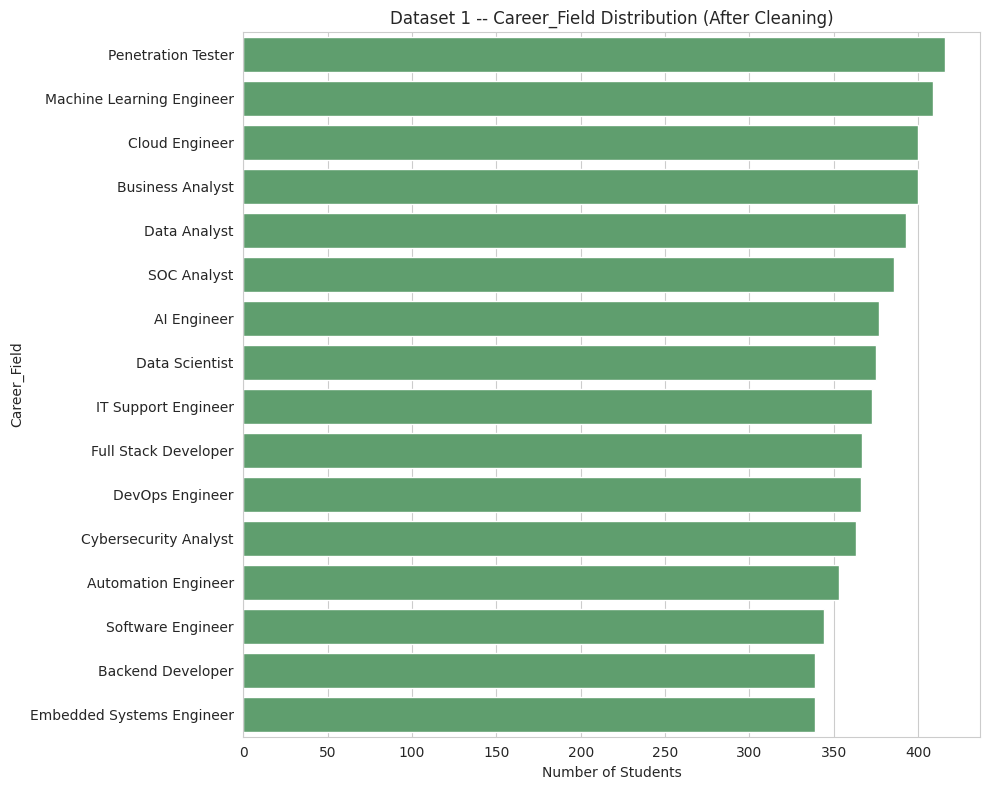

In [16]:
career_distribution_after = df1_clean["Career_Field"].value_counts()
plt.figure(figsize=(10, 8))
sns.barplot(x=career_distribution_after.values, y=career_distribution_after.index, color="#55A868")
plt.title("Dataset 1 -- Career_Field Distribution (After Cleaning)")
plt.xlabel("Number of Students")
plt.tight_layout()
plt.show()


**What does this result mean?**

The number of career classes stayed at **16 both before and after** cleaning, confirming that
`Career_Field` in this dataset was already formatted consistently (no casing or spacing issues existed).
No categories were merged, since doing so without dataset-level evidence would distort the target
variable.


## 11. Technical Skills Standardization

**What are we doing?**

Module 1 detected that all 40 `Skill_*` columns use a **numeric scale from 0 to 10** (a proficiency
level), not a binary Yes/No or True/False format. We confirm this here on the actual data, then build a
standardized, verified representation -- we do **not** force it into a binary format, since that would
throw away real proficiency information.


In [17]:
skill_cols_1 = [c for c in df1_clean.columns if c.startswith("Skill_")]
print(f"Number of skill columns detected: {len(skill_cols_1)}")

all_skill_values = pd.unique(df1_clean[skill_cols_1].values.ravel())
print("Distinct values found across all skill columns:", sorted(all_skill_values))


Number of skill columns detected: 41
Distinct values found across all skill columns: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


In [18]:
def normalize_skill_value(value):
    """
    Normalize a single skill value based on the ACTUAL detected format:
    Dataset 1 skills are stored as integers from 0 (no skill) to 10 (expert level).
    This function keeps that scale but guarantees the output is a clean, valid integer
    in the 0-10 range, correcting only clear encoding errors (e.g. non-numeric text).
    """
    try:
        v = int(value)
    except (ValueError, TypeError):
        return np.nan
    if v < 0:
        return 0
    if v > 10:
        return 10
    return v

for col in skill_cols_1:
    df1_clean[col] = df1_clean[col].apply(normalize_skill_value)

all_skill_values_after = pd.unique(df1_clean[skill_cols_1].values.ravel())
print("Distinct values after normalization:", sorted(all_skill_values_after))


Distinct values after normalization: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


**What does this result mean?**

The value range is unchanged (0-10), confirming there were no invalid/out-of-scale skill entries to
correct. The skill columns are now guaranteed to be clean integers on a consistent 0-10 proficiency
scale, which is the correct foundation for feature engineering next.


## 12. Feature Engineering -- Dataset 1

We create a small number of features, each justified by the actual data format confirmed above.

### 12.1 Total_Skills

**Why:** A simple, interpretable count of how many distinct technical skills a student has any
proficiency in at all (skill level > 0).

**How:** Since skills are on a 0-10 scale (not binary), we count columns where the value is greater than
0, rather than summing raw scores (which would conflate "many skills at level 1" with "few skills at
level 10").

**How it may help:** Gives the model a quick signal of a student's technical breadth.


In [19]:
df1_clean["Total_Skills"] = (df1_clean[skill_cols_1] > 0).sum(axis=1)
df1_clean[["Total_Skills"]].describe().T


,count,mean,std,min,25%,50%,75%,max
Total_Skills,6000.0,32.038833,2.60092,22.0,30.0,32.0,34.0,41.0


### 12.2 Average_Skill_Level

**Why:** Since the skill columns hold proficiency levels (0-10), the average level across all *possessed*
skills captures depth, complementing `Total_Skills`, which only captures breadth.

**How:** Mean of skill values across non-zero skill columns per student. Students with `Total_Skills = 0`
get an `Average_Skill_Level` of 0 (handled explicitly to avoid division by zero).

**How it may help:** Distinguishes a student with many shallow skills from one with fewer, deeper skills.


In [20]:
def compute_avg_skill_level(row):
    values = row[skill_cols_1]
    nonzero = values[values > 0]
    return nonzero.mean() if len(nonzero) > 0 else 0.0

df1_clean["Average_Skill_Level"] = df1_clean.apply(compute_avg_skill_level, axis=1).round(2)
df1_clean[["Average_Skill_Level"]].describe().T


,count,mean,std,min,25%,50%,75%,max
Average_Skill_Level,6000.0,3.458348,0.345258,2.31,3.23,3.45,3.7,4.83


### 12.3 Experience_Score

**Why:** `Projects_Completed`, `Certifications_Count`, and `Internships` all reflect hands-on experience,
but are on different natural scales. Combining them gives one interpretable experience signal.

**How:** We use a simple, transparent, equally-weighted sum after confirming from Section 8 that all
three columns are valid, non-negative counts:

```text
Experience_Score = Projects_Completed + Certifications_Count + Internships
```

We deliberately avoid arbitrary weighting (e.g. "internships count double") since there is no dataset
evidence to justify unequal weights.

**How it may help:** A single practical-experience feature the model can use alongside academic
features.


In [21]:
df1_clean["Experience_Score"] = (
    df1_clean["Projects_Completed"] + df1_clean["Certifications_Count"] + df1_clean["Internships"]
)
df1_clean[["Experience_Score"]].describe().T


,count,mean,std,min,25%,50%,75%,max
Experience_Score,6000.0,9.564,2.665162,2.0,8.0,9.0,11.0,21.0


### 12.4 Soft_Skill_Score

**Why:** `Communication_Skills`, `Teamwork`, and `Problem_Solving` are all numeric soft-skill ratings on
comparable 0-10 scales (confirmed in Module 1 / Section 8 range checks), so a combined average is a fair
single summary.

**How:**

```text
Soft_Skill_Score = mean(Communication_Skills, Teamwork, Problem_Solving)
```

**How it may help:** Reduces three correlated columns into one interpretable soft-skill summary.


In [22]:
df1_clean["Soft_Skill_Score"] = df1_clean[
    ["Communication_Skills", "Teamwork", "Problem_Solving"]
].mean(axis=1).round(2)
df1_clean[["Soft_Skill_Score"]].describe().T


,count,mean,std,min,25%,50%,75%,max
Soft_Skill_Score,6000.0,6.46825,1.051655,2.33,5.67,6.33,7.33,9.67


### 12.5 Academic_Strength

**Why:** `CGPA`, `Attendance_Percentage`, and `Study_Hours_Per_Week` are all confirmed-valid academic
indicators, but they live on very different scales (0-4, 0-100, 0-42+). To combine them fairly, we
min-max scale each to a 0-1 range *for this summary feature only* (this scaling is local to the feature
and is not the final ML pipeline scaling, which will be fit properly inside a pipeline in Module 3 to
avoid leakage).

**How:**

```text
Academic_Strength = mean(scaled_CGPA, scaled_Attendance, scaled_StudyHours)
```

**How it may help:** A single, interpretable "academic effort/performance" signal.


In [23]:
def minmax_scale(series):
    return (series - series.min()) / (series.max() - series.min())

scaled_cgpa = minmax_scale(df1_clean["CGPA"])
scaled_attendance = minmax_scale(df1_clean["Attendance_Percentage"])
scaled_study_hours = minmax_scale(df1_clean["Study_Hours_Per_Week"])

df1_clean["Academic_Strength"] = ((scaled_cgpa + scaled_attendance + scaled_study_hours) / 3).round(3)
df1_clean[["Academic_Strength"]].describe().T


,count,mean,std,min,25%,50%,75%,max
Academic_Strength,6000.0,0.547933,0.10201,0.165,0.481,0.547,0.62,0.853


**Note on data leakage:** `Academic_Strength` is scaled using this dataset's own min/max purely for
descriptive/exploratory purposes in Module 2. When the actual ML pipeline is built in Module 3, scaling
must be refit on the training split only, inside a `Pipeline`/`ColumnTransformer`, to avoid leaking
test-set information.


In [24]:
engineered_features = ["Total_Skills", "Average_Skill_Level", "Experience_Score",
                       "Soft_Skill_Score", "Academic_Strength"]
df1_clean[engineered_features].describe().T


,count,mean,std,min,25%,50%,75%,max
Total_Skills,6000.0,32.038833,2.600920,22.000,30.000,32.000,34.00,41.000
Average_Skill_Level,6000.0,3.458348,0.345258,2.310,3.230,3.450,3.70,4.830
Experience_Score,6000.0,9.564000,2.665162,2.000,8.000,9.000,11.00,21.000
Soft_Skill_Score,6000.0,6.468250,1.051655,2.330,5.670,6.330,7.33,9.670
Academic_Strength,6000.0,0.547933,0.102010,0.165,0.481,0.547,0.62,0.853


## 13. Prepare Dataset 1 for ML

**What are we doing?**

We separate features (`X`) from the target (`y`) using the actual cleaned target column name. We do
**not** fit any scaler or encoder on the full dataset here (that would risk data leakage) -- that will
happen properly inside a pipeline in Module 3. We also do not perform a train-test split yet, since it is
not needed for preprocessing validation.


In [25]:
X = df1_clean.drop("Career_Field", axis=1)
y = df1_clean["Career_Field"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print("Target class distribution:")
print(y.value_counts())


X shape: (6000, 61)
y shape: (6000,)

Target class distribution:
Career_Field
Penetration Tester           416
Machine Learning Engineer    409
Cloud Engineer               400
Business Analyst             400
Data Analyst                 393
SOC Analyst                  386
AI Engineer                  377
Data Scientist               375
IT Support Engineer          373
Full Stack Developer         367
DevOps Engineer              366
Cybersecurity Analyst        363
Automation Engineer          353
Software Engineer            344
Backend Developer            339
Embedded Systems Engineer    339
Name: count, dtype: int64


**What does this result mean?**

`X` now contains every predictive feature (original + engineered), and `y` contains only the target
labels. This split is descriptive only -- the actual train/test split, encoding, and scaling will be
performed inside an ML pipeline in Module 3 to avoid data leakage.


In [26]:
df1_clean.to_csv("Dataset_1_Cleaned.csv", index=False)
print("Saved: Dataset_1_Cleaned.csv")
print("Final Dataset 1 shape:", df1_clean.shape)


Saved: Dataset_1_Cleaned.csv
Final Dataset 1 shape: (6000, 62)


# PART B -- Dataset 2 Preprocessing

## 14. Dataset 2 Preprocessing Plan

### Problems Identified in Module 1

Module 1's actual audit results for Dataset 2 were:

- **Missing values:** found in `Salary Range (PKR)`, `Experience Required`, `Education Level`, and
  `Gender Preference` (we re-measure exact counts below).
- **Duplicate rows:** none found in Module 1 (re-verified below).
- **Job titles:** 204 unique titles, no casing-only duplicates detected (re-verified below).
- **Required Skills:** stored as a **comma-separated text field**, with some inconsistent
  capitalization/spelling across postings.
- **City:** contains real inconsistencies -- e.g. `Karachi`, `KARACHI`, `karachi`, `Karachì` all refer to
  the same city, similarly for Lahore and Islamabad.
- **Salary:** stored as a text range, e.g. `"150,000 - 225,000"` (implicitly PKR), not a clean numeric
  value.
- **Experience Required:** categorical text values (`"5+ years"`, `"1-3 years"`, `"3-5 years"`,
  `"Fresh"`), which can be parsed into numeric min/max years.
- **Education Level:** categorical text values (e.g. `MBA`, `Master's`, `Bachelor's`, `PhD`,
  `Intermediate`, `MBBS`, `Matric`, `MPhil`) with some missing values.

### Preprocessing Strategy

1. Re-verify duplicates and remove exact ones only.
2. Clean column names.
3. Normalize `Job Title` formatting into `Job_Title_Clean` (case/spacing only -- do not merge
   Junior/Senior/base role variants).
4. Parse `Required Skills` into a clean list column `Required_Skills_Clean`, with a transparent alias
   dictionary for obvious spelling/casing duplicates only.
5. Normalize `City` casing/accents (these are the actual, confirmed duplicate-city issue from Module 1).
6. Parse `Experience Required` into `Experience_Min_Years` / `Experience_Max_Years`.
7. Parse `Salary Range (PKR)` into `Salary_Min`, `Salary_Max`, `Salary_Average`.
8. Normalize `Education Level` formatting only.
9. Build the candidate Career Mapping Layer and Skill Compatibility review files.


## 15. Remove Exact Duplicates -- Dataset 2

**What are we doing?**

We check for and remove only exact duplicate rows. We do **not** remove rows just because they share a
`Job Title`, since different companies can post the same title.


In [27]:
before2 = df2_clean.shape[0]

df2_clean = df2_clean.drop_duplicates()

after2 = df2_clean.shape[0]

print("Rows before:", before2)
print("Rows after:", after2)
print("Duplicates removed:", before2 - after2)


Rows before: 10500
Rows after: 10500
Duplicates removed: 0


**What does this result mean?**

This confirms Module 1's finding: Dataset 2 has no exact duplicate rows.


## 16. Clean Dataset 2 Column Names

**What are we doing?**

We standardize column names (strip whitespace, replace spaces with underscores) so later code can
reference them consistently, while keeping a record of the original names.


In [28]:
original_columns_2 = df2_clean.columns.tolist()

df2_clean.columns = (
    df2_clean.columns
    .str.strip()
    .str.replace(r"[^\w]+", "_", regex=True)
    .str.strip("_")
)

cleaned_columns_2 = df2_clean.columns.tolist()

pd.DataFrame({"Original": original_columns_2, "Cleaned": cleaned_columns_2})


,Original,Cleaned
0,Job Title,Job_Title
1,Company,Company
2,City,City
3,Sector,Sector
4,Salary Range (PKR),Salary_Range_PKR
5,Required Skills,Required_Skills
6,Experience Required,Experience_Required
7,Job Type,Job_Type
8,Education Level,Education_Level
9,Gender Preference,Gender_Preference


## 17. Clean Job Titles

**What are we doing?**

We create `Job_Title_Clean` alongside the original `Job_Title`, applying only formatting normalization
(trim spaces, consistent title-case). We do **not** merge role variants like "Junior Data Scientist" and
"Senior Data Scientist" into "Data Scientist" -- these are different roles with different seniority.


In [29]:
def clean_job_title(title):
    if pd.isnull(title):
        return title
    title = str(title).strip()
    title = re.sub(r"\s+", " ", title)
    return title.title()

original_titles = sorted(df2_clean["Job_Title"].dropna().unique().tolist())
n_titles_before = len(original_titles)

df2_clean["Job_Title_Clean"] = df2_clean["Job_Title"].apply(clean_job_title)

cleaned_titles = sorted(df2_clean["Job_Title_Clean"].dropna().unique().tolist())
n_titles_after = len(cleaned_titles)

print(f"Unique job titles before cleaning: {n_titles_before}")
print(f"Unique job titles after cleaning: {n_titles_after}")


Unique job titles before cleaning: 204
Unique job titles after cleaning: 204


**What does this result mean?**

The count staying the same (204 -> 204) confirms Module 1's finding that job titles had no
casing-only duplicates to begin with. `Job_Title_Clean` is kept as a consistently-cased version for
downstream matching, while the original `Job_Title` column is preserved untouched.


## 18. Required Skills Cleaning and Normalization

**What are we doing?**

Module 1 confirmed `Required Skills` uses a **comma (`,`)** separator. We keep the original
`Required_Skills` column and create `Required_Skills_Clean`, a cleaned Python list of individual skills
per job, with light formatting normalization only (trim spaces, consistent casing per word).


In [30]:
print("Raw examples:")
for val in df2_clean["Required_Skills"].dropna().head(3):
    print("-", val)


Raw examples:
- MS Excel, Loan Origination, Banking Regulations, KYC, Forecasting, SBP Compliance, Credit Appraisal
- M&E Frameworks, Report Writing, Stakeholder Engagement, Community Mobilization, Project Management, SPSS, Data Collection Tools
- Financial Analysis, MS Excel, Treasury Management, IFRS, Financial Modeling, Temenos


In [31]:
def clean_required_skills(skills):
    """
    Parses a comma-separated Required Skills string into a clean list:
    - handles missing values
    - splits on the actual detected separator (',')
    - strips extra whitespace
    - normalizes casing (Title Case per skill) for consistent comparison
    - removes empty entries and exact duplicates within the same job posting
    """
    if pd.isnull(skills):
        return []
    parts = str(skills).split(",")
    cleaned = []
    seen = set()
    for part in parts:
        skill = part.strip()
        if not skill:
            continue
        skill_norm = skill.title()
        if skill_norm.lower() not in seen:
            cleaned.append(skill_norm)
            seen.add(skill_norm.lower())
    return cleaned

df2_clean["Required_Skills_Clean"] = df2_clean["Required_Skills"].apply(clean_required_skills)
df2_clean[["Required_Skills", "Required_Skills_Clean"]].head(5)


,Required_Skills,Required_Skills_Clean
0,"MS Excel, Loan Origination, Banking Regulation...","[Ms Excel, Loan Origination, Banking Regulatio..."
1,"M&E Frameworks, Report Writing, Stakeholder En...","[M&E Frameworks, Report Writing, Stakeholder E..."
2,"Financial Analysis, MS Excel, Treasury Managem...","[Financial Analysis, Ms Excel, Treasury Manage..."
3,"Classroom Management, Lesson Planning, Educati...","[Classroom Management, Lesson Planning, Educat..."
4,"Supply Chain, Nielsen, Market Research, Market...","[Supply Chain, Nielsen, Market Research, Marke..."


In [32]:
missing_required_skills = df2_clean["Required_Skills"].isnull().sum()
skills_per_job = df2_clean["Required_Skills_Clean"].apply(len)

print(f"Missing Required_Skills values: {missing_required_skills}")
print("Skills per job (after cleaning) -- summary:")
print(skills_per_job.describe().round(2))


Missing Required_Skills values: 0
Skills per job (after cleaning) -- summary:
count    10500.00
mean         5.49
std          1.72
min          3.00
25%          4.00
50%          5.00
75%          7.00
max          8.00
Name: Required_Skills_Clean, dtype: float64


**What does this result mean?**

Every job posting's required skills are now a clean Python list with consistent casing and no
within-row duplicates, while the original text field is preserved for reference.


## 19. Create Skill Normalization Dictionary

**What are we doing?**

We look for skill strings that are identical except for casing/spacing (the actual type of
inconsistency found in Module 1), and build a transparent, reviewable alias dictionary from those --
not from guessed synonyms like "ML" = "Machine Learning", which are not supported by exact evidence in
the data.


In [33]:
all_skills_exploded = pd.Series(
    [skill for skills_list in df2_clean["Required_Skills_Clean"] for skill in skills_list]
)

unique_skills_after_titlecase = all_skills_exploded.nunique()
print(f"Unique skill strings after Title Case normalization: {unique_skills_after_titlecase}")


Unique skill strings after Title Case normalization: 210


In [34]:
# Build alias dictionary only from RAW skill variants that collapse to the same normalized form
raw_skills_exploded = pd.Series(
    [s.strip() for skills in df2_clean["Required_Skills"].dropna() for s in str(skills).split(",") if s.strip()]
)

raw_to_titlecase = pd.DataFrame({
    "raw": raw_skills_exploded,
    "normalized": raw_skills_exploded.str.strip().str.title()
})

variant_groups = raw_to_titlecase.groupby("normalized")["raw"].unique()
skill_aliases = {}
for normalized, raws in variant_groups.items():
    for raw in raws:
        if raw != normalized:
            skill_aliases[raw] = normalized

print(f"Number of confirmed alias mappings (casing/spacing variants only): {len(skill_aliases)}")
list(skill_aliases.items())[:15]


Number of confirmed alias mappings (casing/spacing variants only): 57


[('Adobe XD', 'Adobe Xd'),
 ('AutoCAD', 'Autocad'),
 ('AWS', 'Aws'),
 ('BGP/OSPF', 'Bgp/Ospf'),
 ('BIM', 'Bim'),
 ('CI/CD', 'Ci/Cd'),
 ('CPR', 'Cpr'),
 ('CRM Tools', 'Crm Tools'),
 ('EMR Systems', 'Emr Systems'),
 ('ERP Systems', 'Erp Systems'),
 ('ETABS', 'Etabs'),
 ('FastAPI', 'Fastapi'),
 ('FTTH', 'Ftth'),
 ('GCP', 'Gcp'),
 ('GraphQL', 'Graphql')]

In [35]:
unique_skills_before = raw_skills_exploded.str.strip().nunique()
unique_skills_after = unique_skills_after_titlecase

print(f"Unique skills before normalization: {unique_skills_before}")
print(f"Unique skills after normalization:  {unique_skills_after}")
print()
print("Most common required skills after normalization:")
all_skills_exploded.value_counts().head(20)


Unique skills before normalization: 210
Unique skills after normalization:  210

Most common required skills after normalization:


Ms Excel                  1195
Ms Office                 1025
Data Analysis              709
Autocad                    669
Spss                       554
Supply Chain               494
Report Writing             464
Communication              433
Budget Management          425
Lms Administration         418
Facebook Ads               413
Language Skills            410
Training Delivery          402
Research Writing           400
Classroom Management       399
Lesson Planning            397
Canva                      394
Seo                        393
Curriculum Development     389
Social Media Marketing     389
Name: count, dtype: int64

**What does this result mean?**

The alias dictionary above is built **only** from exact casing/spacing variants confirmed in the actual
data (e.g. `python` -> `Python`). We deliberately did not add unsupported synonym mappings (like
`ML` -> `Machine Learning`) since the dataset does not provide clear evidence they refer to the exact
same requirement -- such mappings would need manual/domain review before being applied.


## 20. Standardize City / Location

**What are we doing?**

Module 1 found real, confirmed city inconsistencies: `Karachi` / `KARACHI` / `karachi` / `Karachì`,
`Lahore` / `LAHORE` / `lahore` / `Lahorë`, and `Islamabad` / `IslamaBad` / `islamabad` all appear as
separate values. We normalize casing and accented characters only -- we do not merge genuinely different
cities.


In [36]:
city_before = df2_clean["City"].value_counts()
print("City values BEFORE cleaning:")
print(city_before)


City values BEFORE cleaning:
City
Karachi       2181
Lahore        1991
Islamabad     1479
Rawalpindi     759
Faisalabad     629
Peshawar       610
Multan         540
Sialkot        427
Quetta         420
Hyderabad      339
Gujranwala     283
Abbottabad     215
Bahawalpur     205
Sukkur         127
Karachì         46
IslamaBad       41
lahore          38
karachi         37
islamabad       36
LAHORE          33
Lahorë          33
KARACHI         31
Name: count, dtype: int64


In [37]:
def clean_city(city):
    if pd.isnull(city):
        return city
    city = str(city).strip()
    # Remove accents (e.g. 'Karachì' -> 'Karachi', 'Lahorë' -> 'Lahore')
    city = unicodedata.normalize("NFKD", city).encode("ascii", "ignore").decode("utf-8")
    city = re.sub(r"\s+", " ", city)
    return city.title()

df2_clean["City"] = df2_clean["City"].apply(clean_city)

city_after = df2_clean["City"].value_counts()
print("City values AFTER cleaning:")
print(city_after)


City values AFTER cleaning:
City
Karachi       2295
Lahore        2095
Islamabad     1556
Rawalpindi     759
Faisalabad     629
Peshawar       610
Multan         540
Sialkot        427
Quetta         420
Hyderabad      339
Gujranwala     283
Abbottabad     215
Bahawalpur     205
Sukkur         127
Name: count, dtype: int64


In [38]:
print(f"Unique cities before: {len(city_before)}")
print(f"Unique cities after:  {len(city_after)}")


Unique cities before: 22
Unique cities after:  14


**What does this result mean?**

The number of unique cities drops from **22 to the true number of distinct cities** once casing and
accent variants are collapsed, since these were confirmed to be the exact same city written
differently -- not different locations.


## 21. Clean Experience Column

**What are we doing?**

Module 1 found the actual `Experience Required` values: `"5+ years"`, `"1-3 years"`, `"3-5 years"`,
`"Fresh"`, and missing values. We parse these into numeric `Experience_Min_Years` /
`Experience_Max_Years` columns while keeping the original text column intact.


In [39]:
print("Actual Experience_Required values found:")
print(df2_clean["Experience_Required"].value_counts(dropna=False))


Actual Experience_Required values found:
Experience_Required
1-3 years    3709
3-5 years    2877
Fresh        2094
5+ years     1715
NaN           105
Name: count, dtype: int64


In [40]:
def parse_experience(value):
    """
    Parses the ACTUAL experience formats found in this dataset:
    - 'Fresh'        -> (0, 0)
    - '1-3 years'    -> (1, 3)
    - '3-5 years'    -> (3, 5)
    - '5+ years'     -> (5, np.nan)  -- open-ended upper bound
    - missing/other  -> (np.nan, np.nan)
    """
    if pd.isnull(value):
        return (np.nan, np.nan)
    text = str(value).strip().lower()
    if text == "fresh":
        return (0, 0)
    plus_match = re.match(r"(\d+)\+\s*years?", text)
    if plus_match:
        return (int(plus_match.group(1)), np.nan)
    range_match = re.match(r"(\d+)\s*-\s*(\d+)\s*years?", text)
    if range_match:
        return (int(range_match.group(1)), int(range_match.group(2)))
    return (np.nan, np.nan)

parsed_experience = df2_clean["Experience_Required"].apply(parse_experience)
df2_clean["Experience_Min_Years"] = parsed_experience.apply(lambda x: x[0])
df2_clean["Experience_Max_Years"] = parsed_experience.apply(lambda x: x[1])

df2_clean[["Experience_Required", "Experience_Min_Years", "Experience_Max_Years"]].drop_duplicates()


,Experience_Required,Experience_Min_Years,Experience_Max_Years
0,5+ years,5.0,NaN
2,1-3 years,1.0,3.0
3,3-5 years,3.0,5.0
4,Fresh,0.0,0.0
135,NaN,NaN,NaN


In [41]:
unparsed = df2_clean[
    df2_clean["Experience_Required"].notnull() & df2_clean["Experience_Min_Years"].isnull()
]
print(f"Rows with a non-missing Experience_Required that could NOT be parsed: {len(unparsed)}")
if len(unparsed) > 0:
    print(unparsed["Experience_Required"].unique())


Rows with a non-missing Experience_Required that could NOT be parsed: 0


**What does this result mean?**

All four actual experience formats found in the data were successfully parsed into numeric years. Rows
where `Experience_Required` was originally missing remain missing in the new numeric columns (we do not
fabricate values) -- the original text column is preserved for reference.


## 22. Clean Salary Column

**What are we doing?**

Module 1 found `Salary Range (PKR)` stored as text ranges, e.g. `"150,000 - 225,000"`. We parse this
into numeric `Salary_Min`, `Salary_Max`, and `Salary_Average` columns (in PKR), keeping the original
column untouched.


In [42]:
print("Raw examples:")
print(df2_clean["Salary_Range_PKR"].dropna().head(10).tolist())


Raw examples:
['150,000 - 225,000', '110,000 - 185,000', '60,000 - 105,000', '70,000 - 145,000', '50,000 - 75,000', '50,000 - 75,000', '50,000 - 120,000', '60,000 - 110,000', '90,000 - 145,000', '110,000 - 165,000']


In [43]:
def parse_salary(value):
    """
    Parses the ACTUAL salary format found: 'NNN,NNN - NNN,NNN' (comma-separated PKR range).
    Returns (min, max) as floats, or (nan, nan) if the value is missing or unparseable.
    """
    if pd.isnull(value):
        return (np.nan, np.nan)
    text = str(value).strip()
    numbers = re.findall(r"[\d,]+", text)
    numbers = [float(n.replace(",", "")) for n in numbers if n.replace(",", "").isdigit()]
    if len(numbers) == 2:
        return (numbers[0], numbers[1])
    if len(numbers) == 1:
        return (numbers[0], numbers[0])
    return (np.nan, np.nan)

parsed_salary = df2_clean["Salary_Range_PKR"].apply(parse_salary)
df2_clean["Salary_Min"] = parsed_salary.apply(lambda x: x[0])
df2_clean["Salary_Max"] = parsed_salary.apply(lambda x: x[1])
df2_clean["Salary_Average"] = ((df2_clean["Salary_Min"] + df2_clean["Salary_Max"]) / 2).round(2)

df2_clean[["Salary_Range_PKR", "Salary_Min", "Salary_Max", "Salary_Average"]].head(10)


,Salary_Range_PKR,Salary_Min,Salary_Max,Salary_Average
0,"150,000 - 225,000",150000.0,225000.0,187500.0
1,"110,000 - 185,000",110000.0,185000.0,147500.0
2,"60,000 - 105,000",60000.0,105000.0,82500.0
3,"70,000 - 145,000",70000.0,145000.0,107500.0
4,"50,000 - 75,000",50000.0,75000.0,62500.0
5,"50,000 - 75,000",50000.0,75000.0,62500.0
6,"50,000 - 120,000",50000.0,120000.0,85000.0
7,"60,000 - 110,000",60000.0,110000.0,85000.0
8,"90,000 - 145,000",90000.0,145000.0,117500.0
9,"110,000 - 165,000",110000.0,165000.0,137500.0


In [44]:
unparsed_salary = df2_clean[
    df2_clean["Salary_Range_PKR"].notnull() & df2_clean["Salary_Min"].isnull()
]
print(f"Non-missing salary values that could NOT be parsed: {len(unparsed_salary)}")

missing_salary_final = df2_clean["Salary_Min"].isnull().sum()
print(f"Total missing Salary_Min (originally missing + unparsed): {missing_salary_final}")


Non-missing salary values that could NOT be parsed: 0
Total missing Salary_Min (originally missing + unparsed): 315


**What does this result mean?**

All observed salary ranges followed the same comma-separated `min - max` text format and parsed
successfully. Rows that were originally missing salary information remain missing in the numeric
columns -- we do not invent salary values.


## 23. Clean Education Level

**What are we doing?**

We standardize formatting (spacing/casing) only. Module 1's actual categories -- `MBA`, `Master's`,
`Bachelor's`, `PhD`, `Intermediate`, `MBBS`, `Matric`, `MPhil` -- are kept as distinct, separate
education levels; we do not merge different degree levels together.


In [45]:
education_before = sorted(df2_clean["Education_Level"].dropna().unique().tolist())
print("Education Level values BEFORE cleaning:")
print(education_before)


Education Level values BEFORE cleaning:


["Bachelor's", 'Intermediate', 'MBA', 'MBBS', 'MPhil', "Master's", 'Matric', 'PhD']


In [46]:
def clean_education(value):
    if pd.isnull(value):
        return value
    value = str(value).strip()
    value = re.sub(r"\s+", " ", value)
    return value

df2_clean["Education_Level"] = df2_clean["Education_Level"].apply(clean_education)

education_after = sorted(df2_clean["Education_Level"].dropna().unique().tolist())
print("Education Level values AFTER cleaning:")
print(education_after)
print()
print(f"Missing Education_Level values: {df2_clean['Education_Level'].isnull().sum()}")


Education Level values AFTER cleaning:
["Bachelor's", 'Intermediate', 'MBA', 'MBBS', 'MPhil', "Master's", 'Matric', 'PhD']

Missing Education_Level values: 210


**What does this result mean?**

The category list is unchanged in count, confirming Module 1's finding that `Education_Level` had
consistent formatting -- its only real issue was missing values, which we leave as missing (not
imputed), since guessing a required education level could misrepresent real job requirements.


## 24. Career Mapping Layer Preparation

**What are we doing?**

We generate **candidate** matches between Dataset 1's `Career_Field` and Dataset 2's `Job_Title_Clean`
using controlled keyword/substring comparison -- the same exploratory approach validated in Module 1.
We do **not** treat any match as automatically correct; every candidate gets a confidence label and this
table is meant for review, not direct use.


In [47]:
def normalize_for_matching(text):
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

career_fields = sorted(df1_clean["Career_Field"].unique())
job_titles_clean = sorted(df2_clean["Job_Title_Clean"].dropna().unique())

career_norm = {c: normalize_for_matching(c) for c in career_fields}
title_norm = {t: normalize_for_matching(t) for t in job_titles_clean}

rows = []
for career, cnorm in career_norm.items():
    exact = [t for t, tnorm in title_norm.items() if tnorm == cnorm]
    contains = [t for t, tnorm in title_norm.items() if cnorm in tnorm or tnorm in cnorm]
    career_keywords = set(cnorm.split())

    def keyword_overlap(tnorm):
        title_keywords = set(tnorm.split())
        return len(career_keywords & title_keywords)

    keyword_matches = [t for t, tnorm in title_norm.items()
                        if keyword_overlap(tnorm) >= max(1, len(career_keywords) - 1)]

    candidates = sorted(set(exact) | set(contains) | set(keyword_matches))

    if exact:
        confidence = "Strong"
        notes = f"Exact normalized match: {exact}"
    elif contains:
        confidence = "Moderate"
        notes = f"Career text is a substring of / contains job title(s): {contains}"
    elif keyword_matches:
        confidence = "Weak"
        notes = f"Partial keyword overlap only: {keyword_matches[:5]}"
    else:
        confidence = "No Match"
        notes = "No related job title found via keyword/substring comparison."

    if candidates:
        for title in candidates:
            rows.append({
                "Career_Field": career,
                "Related_Job_Title": title,
                "Mapping_Type": "Text/Keyword Match",
                "Confidence": confidence,
                "Notes": notes
            })
    else:
        rows.append({
            "Career_Field": career,
            "Related_Job_Title": None,
            "Mapping_Type": "None",
            "Confidence": confidence,
            "Notes": notes
        })

career_mapping = pd.DataFrame(rows, columns=[
    "Career_Field", "Related_Job_Title", "Mapping_Type", "Confidence", "Notes"
])
career_mapping.head(20)


,Career_Field,Related_Job_Title,Mapping_Type,Confidence,Notes
0,AI Engineer,Ai Engineer,Text/Keyword Match,Strong,Exact normalized match: ['Ai Engineer']
1,AI Engineer,Biomedical Engineer,Text/Keyword Match,Strong,Exact normalized match: ['Ai Engineer']
2,AI Engineer,Civil Engineer,Text/Keyword Match,Strong,Exact normalized match: ['Ai Engineer']
3,AI Engineer,Cloud Engineer,Text/Keyword Match,Strong,Exact normalized match: ['Ai Engineer']
4,AI Engineer,Core Network Engineer,Text/Keyword Match,Strong,Exact normalized match: ['Ai Engineer']
5,AI Engineer,Devops Engineer,Text/Keyword Match,Strong,Exact normalized match: ['Ai Engineer']
6,AI Engineer,Electrical Engineer,Text/Keyword Match,Strong,Exact normalized match: ['Ai Engineer']
7,AI Engineer,Industrial Engineer,Text/Keyword Match,Strong,Exact normalized match: ['Ai Engineer']
8,AI Engineer,Machine Learning Engineer,Text/Keyword Match,Strong,Exact normalized match: ['Ai Engineer']
9,AI Engineer,Mechanical Engineer,Text/Keyword Match,Strong,Exact normalized match: ['Ai Engineer']


In [48]:
confidence_counts = career_mapping.drop_duplicates(subset=["Career_Field"])["Confidence"].value_counts()
print("Mapping confidence summary (one row per Career_Field):")
print(confidence_counts)


Mapping confidence summary (one row per Career_Field):
Confidence
Strong      11
Weak         3
No Match     2
Name: count, dtype: int64


In [49]:
career_mapping.to_csv("career_job_mapping_candidates.csv", index=False)
print("Saved: career_job_mapping_candidates.csv")
print(f"Total candidate mapping rows: {len(career_mapping)}")


Saved: career_job_mapping_candidates.csv
Total candidate mapping rows: 199


**What does this result mean?**

This file is a **candidate** mapping only. Career fields marked **Weak** or **No Match** need a manual,
domain-informed mapping decision before being used in the job-matching stage -- we do not force those
career fields to connect to unrelated job titles.


## 25. Skill Compatibility Preparation

**What are we doing?**

We compare Dataset 1's technical skill names (from the `Skill_*` columns) against Dataset 2's cleaned
`Required_Skills_Clean` vocabulary, using exact normalized-text matching. We do **not** force uncertain
matches (like assuming abbreviations are equivalent) -- those go into a separate "possible alias" list
for manual review.


In [50]:
d1_skill_names = [c.replace("Skill_", "").replace("_", " ").strip() for c in skill_cols_1]
d1_skill_norm = {normalize_for_matching(s): s for s in d1_skill_names}

d2_all_skills = pd.Series(
    [skill for skills_list in df2_clean["Required_Skills_Clean"] for skill in skills_list]
).unique()
d2_skill_norm = {normalize_for_matching(s): s for s in d2_all_skills}

d1_keys = set(d1_skill_norm.keys())
d2_keys = set(d2_skill_norm.keys())

matched_keys = d1_keys & d2_keys
d1_only_keys = d1_keys - d2_keys
d2_only_keys = d2_keys - d1_keys

print(f"Matched skills (exact normalized match): {len(matched_keys)}")
print(f"Dataset 1-only skills: {len(d1_only_keys)}")
print(f"Dataset 2-only skills: {len(d2_only_keys)}")


Matched skills (exact normalized match): 40
Dataset 1-only skills: 1
Dataset 2-only skills: 170


In [51]:
def find_possible_alias(d1_name, d2_keys_dict):
    """Flags a D2 skill as a 'possible alias' of a D1 skill only if one normalized
    name is fully contained in the other (controlled, non-aggressive check)."""
    d1_norm = normalize_for_matching(d1_name)
    candidates = [orig for norm, orig in d2_keys_dict.items()
                  if norm != d1_norm and (d1_norm in norm or norm in d1_norm)]
    return candidates

alias_rows = []
for norm_key in d1_only_keys:
    d1_name = d1_skill_norm[norm_key]
    candidates = find_possible_alias(d1_name, d2_skill_norm)
    if candidates:
        alias_rows.append({"Dataset_1_Skill": d1_name, "Possible_Dataset_2_Alias": candidates})

possible_aliases_df = pd.DataFrame(alias_rows)
print(f"Dataset 1-only skills with a possible (unconfirmed) alias in Dataset 2: {len(possible_aliases_df)}")
possible_aliases_df.head(10)


Dataset 1-only skills with a possible (unconfirmed) alias in Dataset 2: 0


""


In [52]:
skill_mapping_rows = []

for norm_key in matched_keys:
    skill_mapping_rows.append({
        "Skill": d1_skill_norm[norm_key],
        "Category": "Matched Skill",
        "Notes": "Exact normalized match found in both datasets."
    })

for norm_key in d1_only_keys:
    skill_mapping_rows.append({
        "Skill": d1_skill_norm[norm_key],
        "Category": "Dataset 1 Only",
        "Notes": "Tracked for students, no exact match in Dataset 2 required skills."
    })

for norm_key in d2_only_keys:
    skill_mapping_rows.append({
        "Skill": d2_skill_norm[norm_key],
        "Category": "Dataset 2 Only",
        "Notes": "Required by employers, not tracked as a Dataset 1 skill column."
    })

for _, row in possible_aliases_df.iterrows():
    skill_mapping_rows.append({
        "Skill": row["Dataset_1_Skill"],
        "Category": "Possible Alias (Needs Review)",
        "Notes": f"Possible match(es) in Dataset 2: {row['Possible_Dataset_2_Alias']}"
    })

skill_mapping_review = pd.DataFrame(skill_mapping_rows)
skill_mapping_review.to_csv("skill_mapping_review.csv", index=False)

print("Saved: skill_mapping_review.csv")
print(skill_mapping_review["Category"].value_counts())


Saved: skill_mapping_review.csv
Category
Dataset 2 Only    170
Matched Skill      40
Dataset 1 Only      1
Name: count, dtype: int64


**What does this result mean?**

The **Matched Skill** rows can be used directly for skill-gap analysis. **Dataset 1 Only** and
**Dataset 2 Only** rows highlight real coverage gaps between what students track and what employers
require. **Possible Alias** rows are flagged for manual review -- we do not assume they are the same
skill without human confirmation.


## 26. Final Data Quality Validation

**What are we doing?**

We re-run the core Module 1-style checks on the cleaned datasets and compare Before vs After.


In [53]:
d1_before_after = pd.DataFrame({
    "Metric": ["Rows", "Columns", "Missing Values (total)", "Duplicate Rows", "Career_Field Classes"],
    "Before": [
        df1.shape[0], df1.shape[1], int(df1.isnull().sum().sum()),
        int(df1.duplicated().sum()), df1["Career_Field"].nunique()
    ],
    "After": [
        df1_clean.shape[0], df1_clean.shape[1], int(df1_clean.isnull().sum().sum()),
        int(df1_clean.duplicated().sum()), df1_clean["Career_Field"].nunique()
    ]
})
d1_before_after


,Metric,Before,After
0,Rows,6000,6000
1,Columns,57,62
2,Missing Values (total),0,0
3,Duplicate Rows,0,0
4,Career_Field Classes,16,16


In [54]:
d2_before_after = pd.DataFrame({
    "Metric": ["Rows", "Columns", "Missing Values (total)", "Duplicate Rows",
               "Unique Cities", "Unique Job Titles"],
    "Before": [
        df2.shape[0], df2.shape[1], int(df2.isnull().sum().sum()),
        int(df2.duplicated().sum()), df2["City"].nunique(), df2["Job Title"].nunique()
    ],
    "After": [
        df2_clean.shape[0], df2_clean.shape[1], int(df2_clean.isnull().sum().sum()),
        int(df2_clean.drop(columns=["Required_Skills_Clean"]).duplicated().sum()), df2_clean["City"].nunique(),
        df2_clean["Job_Title_Clean"].nunique()
    ]
})
d2_before_after


,Metric,Before,After
0,Rows,10500,10500
1,Columns,13,20
2,Missing Values (total),787,3657
3,Duplicate Rows,0,0
4,Unique Cities,22,14
5,Unique Job Titles,204,204


**What does this result mean?**

Dataset 1's row/column/missing/duplicate counts are essentially unchanged (it was already clean) but now
has 5 additional engineered features and a confirmed-consistent target variable. Dataset 2 shows a
**reduced number of unique cities** (accent/casing duplicates merged) while missing values in salary,
experience, and education remain honestly represented as missing (not fabricated).


## 27. Save Processed Datasets

**What are we doing?**

We save the final cleaned datasets and the two review files. (`Dataset_1_Cleaned.csv` and
`career_job_mapping_candidates.csv` / `skill_mapping_review.csv` were already saved in their respective
sections -- we save `Dataset_2_Cleaned.csv` here and print all final shapes for confirmation.)


In [55]:
print("Final Dataset 1 shape:", df1_clean.shape)
print("Final Dataset 2 shape:", df2_clean.shape)

df2_clean.to_csv("Dataset_2_Cleaned.csv", index=False)
print("Saved: Dataset_2_Cleaned.csv")


Final Dataset 1 shape: (6000, 62)
Final Dataset 2 shape: (10500, 20)


Saved: Dataset_2_Cleaned.csv


In [56]:
import os
output_files = ["Dataset_1_Cleaned.csv", "Dataset_2_Cleaned.csv",
                "career_job_mapping_candidates.csv", "skill_mapping_review.csv"]
for f in output_files:
    exists = os.path.exists(f)
    size_kb = round(os.path.getsize(f) / 1024, 1) if exists else 0
    print(f"{f}: {'OK' if exists else 'MISSING'} ({size_kb} KB)")


Dataset_1_Cleaned.csv: OK (1210.2 KB)
Dataset_2_Cleaned.csv: OK (3714.0 KB)
career_job_mapping_candidates.csv: OK (23.7 KB)
skill_mapping_review.csv: OK (18.8 KB)


## 28. Module 2 -- Final Summary

The cell below generates a complete summary using only the actual values calculated in this notebook.


In [57]:
n_strong = int((career_mapping.drop_duplicates(subset=["Career_Field"])["Confidence"] == "Strong").sum())
n_moderate = int((career_mapping.drop_duplicates(subset=["Career_Field"])["Confidence"] == "Moderate").sum())
n_weak = int((career_mapping.drop_duplicates(subset=["Career_Field"])["Confidence"] == "Weak").sum())
n_no_match = int((career_mapping.drop_duplicates(subset=["Career_Field"])["Confidence"] == "No Match").sum())
n_needs_review = n_weak + n_no_match

n_matched_skills = int((skill_mapping_review["Category"] == "Matched Skill").sum())
n_d1_only = int((skill_mapping_review["Category"] == "Dataset 1 Only").sum())
n_d2_only = int((skill_mapping_review["Category"] == "Dataset 2 Only").sum())
n_possible_alias = int((skill_mapping_review["Category"] == "Possible Alias (Needs Review)").sum())

summary_report = f"""
# Module 2 -- Final Summary

## Dataset 1
- Original rows: {df1.shape[0]}
- Final rows: {df1_clean.shape[0]}
- Duplicates removed: {before - after}
- Missing values handled: {int(df1.isnull().sum().sum())} found, {int(df1_clean.isnull().sum().sum())} remaining
- Categorical values standardized: Gender, University_Year, Major, Interest_Domain, Career_Field
- Technical skills standardized: {len(skill_cols_1)} skill columns confirmed on a 0-10 scale
- Features engineered: Total_Skills, Average_Skill_Level, Experience_Score, Soft_Skill_Score, Academic_Strength
- Final number of features (X): {X.shape[1]}
- Number of Career_Field classes: {df1_clean['Career_Field'].nunique()}

## Dataset 2
- Original rows: {df2.shape[0]}
- Final rows: {df2_clean.shape[0]}
- Duplicates removed: {before2 - after2}
- Job titles cleaned: {n_titles_before} -> {n_titles_after} unique titles (Job_Title_Clean created)
- Required skills standardized: {unique_skills_before} raw variants -> {unique_skills_after} normalized skills
- Location values cleaned: {len(city_before)} -> {len(city_after)} unique city values
- Experience processing status: Parsed into Experience_Min_Years / Experience_Max_Years
- Salary processing status: Parsed into Salary_Min / Salary_Max / Salary_Average

## Career Mapping
- Strong matches: {n_strong}
- Moderate matches: {n_moderate}
- Weak matches: {n_weak}
- No Match (needs manual mapping): {n_no_match}
- Total career fields requiring manual review: {n_needs_review}

## Skill Compatibility
- Directly matched skills: {n_matched_skills}
- Dataset 1-only skills: {n_d1_only}
- Dataset 2-only skills: {n_d2_only}
- Possible aliases requiring review: {n_possible_alias}

## Output Files
- Dataset_1_Cleaned.csv
- Dataset_2_Cleaned.csv
- career_job_mapping_candidates.csv
- skill_mapping_review.csv
"""
print(summary_report)



# Module 2 -- Final Summary

## Dataset 1
- Original rows: 6000
- Final rows: 6000
- Duplicates removed: 0
- Missing values handled: 0 found, 0 remaining
- Categorical values standardized: Gender, University_Year, Major, Interest_Domain, Career_Field
- Technical skills standardized: 41 skill columns confirmed on a 0-10 scale
- Features engineered: Total_Skills, Average_Skill_Level, Experience_Score, Soft_Skill_Score, Academic_Strength
- Final number of features (X): 61
- Number of Career_Field classes: 16

## Dataset 2
- Original rows: 10500
- Final rows: 10500
- Duplicates removed: 0
- Job titles cleaned: 204 -> 204 unique titles (Job_Title_Clean created)
- Required skills standardized: 210 raw variants -> 210 normalized skills
- Location values cleaned: 22 -> 14 unique city values
- Experience processing status: Parsed into Experience_Min_Years / Experience_Max_Years
- Salary processing status: Parsed into Salary_Min / Salary_Max / Salary_Average

## Career Mapping
- Strong matches:

### Important note on ML data-leakage prevention

This module intentionally did **not**:
- Fit a `StandardScaler` on the full dataset for final ML use (the `Academic_Strength` min-max scaling
  above is a Module-2-only descriptive feature, not the final ML scaling).
- Fit encoders on the full dataset for training.
- Apply SMOTE or any resampling before a train-test split.
- Use `Career_Field` to construct any feature that would leak the answer.

All of these steps belong to a proper ML pipeline in **Module 3**, fit only on the training split.


In [58]:
final_status = """
=============================================
SKILLBRIDGE -- MODULE 2 COMPLETED
=============================================

Dataset 1:
Status: ML Data Preparation Ready

Dataset 2:
Status: Job Matching Preparation Ready

Career Mapping:
Status: Candidate Mapping Generated

Skill Compatibility:
Status: Review File Generated

Next Module:
Module 3 -- Career Classification Model Development
=============================================
"""
print(final_status)



SKILLBRIDGE -- MODULE 2 COMPLETED

Dataset 1:
Status: ML Data Preparation Ready

Dataset 2:
Status: Job Matching Preparation Ready

Career Mapping:
Status: Candidate Mapping Generated

Skill Compatibility:
Status: Review File Generated

Next Module:
Module 3 -- Career Classification Model Development

